# 02a Redline Bottom ROI Event Probe v1

02에서 확인한 것은 다음이다.

```text
redline은 HSV red + horizontal contour로 꽤 잘 잡힌다.
하지만 전체 이미지 기준 detector로 보면 stop sign 이미지 안의 바닥 빨간 영역까지 많이 잡힌다.
```

이 노트북에서는 문제를 바꾼다.

```text
목표:
  final redline을 물체처럼 예쁘게 검출하는 것이 아니라,
  차량이 빨간 정지 영역에 가까워졌을 때 정지 타이머를 시작할 수 있는지 확인한다.
```

따라서 핵심은 전체 이미지 검출이 아니라 **이미지 하단 ROI 이벤트**다.

```text
bottom ROI에서 빨간 가로 contour가 안정적으로 보인다
→ redline_event_pending
→ stop_delay_sec 뒤에 정지
```

아직 최종 contract 확정은 아니다. 이 노트북은 bottom ROI와 contour 조건을 좁히는 탐색 노트북이다.


## 02a에서 조절하는 값

이 노트북의 조절값은 일부러 적게 둔다.

```text
HSV:
  red_balanced_s100_v80을 기본값으로 사용한다.

bottom ROI:
  roi_y0 = 0.70, 0.75, 0.80, 0.85
  y >= roi_y0 * image_height 영역만 본다.

shape/event 조건:
  min_area          너무 작은 빨간 조각 제거
  min_width_ratio   화면 가로폭 대비 어느 정도 긴 contour인지
  min_aspect_wh     가로로 긴 정도 = bbox width / bbox height
  min_center_overlap 중앙 주행 영역을 얼마나 가로지르는지
```

여기서 `min_center_overlap`은 redline이 단순히 오른쪽/왼쪽 구석에 있는 빨간 조각이 아니라, 주행로 중앙 근처에도 걸쳐 있는지 보는 장치다.


In [1]:
from pathlib import Path
from IPython.display import display, Image
import json
import math
import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / '10_experiments' / '18_opencv_color_event_detector'
DATA_ROOT = PROJECT_ROOT / '20_shared_assets' / 'dataset'
TRAFFIC_ROOT = DATA_ROOT / 'traffic' / 'raw'
REDLINE_ROOT = DATA_ROOT / 'redline' / 'raw'

OUT_ROOT = EXP_ROOT / 'review_outputs' / '02a_redline_bottom_roi_event_probe_v1'
TABLE_DIR = OUT_ROOT / 'tables'
OVERLAY_DIR = OUT_ROOT / 'overlays'
PLOT_DIR = OUT_ROOT / 'plots'
for p in [TABLE_DIR, OVERLAY_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('EXP_ROOT:', EXP_ROOT)
print('REDLINE_ROOT:', REDLINE_ROOT)
print('OUT_ROOT:', OUT_ROOT)


EXP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector
REDLINE_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\redline\raw
OUT_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1


## Windows long-path helper

18번 폴더의 이전 노트북들과 동일하게, 모든 이미지 I/O는 long-path helper를 거친다.


In [2]:
def fs_path(path):
    path = Path(path)
    s = str(path.resolve())
    if os.name == 'nt' and len(s) >= 240 and not s.startswith('\\\\?\\'):
        return '\\\\?\\' + s
    return s

def imread_bgr(path):
    img = cv2.imread(fs_path(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return img

def imwrite(path, img):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ok = cv2.imwrite(fs_path(path), img)
    if not ok:
        raise RuntimeError(f'cv2.imwrite failed: {path}')
    return path

def show_saved_image(path, width=None):
    path = Path(path)
    with open(fs_path(path), 'rb') as f:
        display(Image(data=f.read(), width=width))


## 데이터 index

02와 같은 기준으로 데이터를 나눈다.

```text
positive:
  final_redline

negative/cross-check:
  stop_sign_negative
  traffic_red
  traffic_green
```

주의: `stop_sign_negative` 이미지 중에는 바닥의 빨간 선/빨간 영역이 같이 보이는 프레임이 있다. 따라서 stop false hit는 모두 같은 의미의 오검출은 아니다. overlay로 반드시 같이 확인한다.


In [3]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def iter_images(folder):
    folder = Path(folder)
    for p in sorted(folder.rglob('*')):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            yield p

def redline_role_from_name(name):
    low = name.lower()
    if 'redline' in low or 'finish' in low:
        return 'final_redline'
    if 'stop' in low or 'sign' in low:
        return 'stop_sign_negative'
    return 'other_redline_folder'

def parse_frame_id(name):
    nums = re.findall(r'(\d+)', name)
    if not nums:
        return -1
    return int(nums[-1])

def build_index():
    rows=[]
    for p in iter_images(REDLINE_ROOT):
        role = redline_role_from_name(p.name)
        rows.append({'set':'redline_raw','role':role,'path':str(p),'filename':p.name,'frame_id':parse_frame_id(p.name)})
    for label in ['red','green']:
        for p in iter_images(TRAFFIC_ROOT / label):
            rows.append({'set':'traffic_raw','role':f'traffic_{label}','path':str(p),'filename':p.name,'frame_id':parse_frame_id(p.name)})
    return pd.DataFrame(rows)

index_df = build_index()
index_df.to_csv(TABLE_DIR / 'redline_bottom_roi_index.csv', index=False, encoding='utf-8-sig')
print(index_df.groupby(['set','role']).size())
assert (index_df['role'] == 'final_redline').sum() > 0
assert (index_df['role'] == 'stop_sign_negative').sum() > 0


set          role              
redline_raw  final_redline         101
             stop_sign_negative    233
traffic_raw  traffic_green         313
             traffic_red           343
dtype: int64


## HSV와 mask 생성

02 결과를 바탕으로 기본 HSV는 `red_balanced_s100_v80`을 사용한다.

```text
H: 0~12 또는 168~179
S: 100 이상
V: 80 이상
```

하단 ROI 안에서 얇은 빨간 선이 끊겨 보일 수 있으므로, mask 후처리에는 작은 open/close와 가로 방향 close를 넣는다. 이 후처리는 redline event용이며, traffic light detector와는 목적이 다르다.


In [4]:
RED_HSV_PROFILE = {
    'name': 'red_balanced_s100_v80',
    'ranges': [((0, 100, 80), (12, 255, 255)), ((168, 100, 80), (179, 255, 255))],
}

# 비교용. 최종 후보가 아니라, red_balanced가 너무 넓어 보일 때 참고한다.
RED_HSV_CONTROL = {
    'name': 'red_conservative_s130_v100',
    'ranges': [((0, 130, 100), (10, 255, 255)), ((170, 130, 100), (179, 255, 255))],
}

HSV_PROFILES_TO_EVALUATE = [RED_HSV_PROFILE, RED_HSV_CONTROL]
USE_HORIZONTAL_CLOSE = True

def hsv_mask_from_profile(bgr, profile):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lo, hi in profile['ranges']:
        part = cv2.inRange(hsv, np.array(lo, dtype=np.uint8), np.array(hi, dtype=np.uint8))
        mask = cv2.bitwise_or(mask, part)
    kernel3 = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel3, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel3, iterations=1)
    if USE_HORIZONTAL_CLOSE:
        horiz = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 3))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, horiz, iterations=1)
    return mask

def apply_bottom_roi(mask, roi_y0):
    H, W = mask.shape[:2]
    out = np.zeros_like(mask)
    y0 = int(round(float(roi_y0) * H))
    out[y0:, :] = mask[y0:, :]
    return out


## Bottom ROI와 event shape 후보

아래 후보들은 contract가 아니라 sweep 후보이다.

`bottom80`은 아래쪽 20%만 보는 것이고, `bottom70`은 아래쪽 30%까지 본다. 너무 아래만 보면 redline을 늦게 잡고, 너무 위까지 보면 멀리 있는 선이나 stop sign 주변 바닥 영역까지 잡을 수 있다.


In [5]:
ROI_CANDIDATES = [
    {'name': 'bottom70', 'y0': 0.70},
    {'name': 'bottom75', 'y0': 0.75},
    {'name': 'bottom80', 'y0': 0.80},
    {'name': 'bottom85', 'y0': 0.85},
]

# central_band는 화면 중앙 주행로 근처를 의미한다.
CENTRAL_BAND = (0.35, 0.65)

EVENT_SHAPE_CANDIDATES = [
    {
        'name': 'event_soft',
        'min_area': 350,
        'min_width_ratio': 0.07,
        'min_aspect_wh': 2.0,
        'min_center_overlap': 0.10,
        'min_height': 3,
    },
    {
        'name': 'event_balanced',
        'min_area': 800,
        'min_width_ratio': 0.12,
        'min_aspect_wh': 2.5,
        'min_center_overlap': 0.20,
        'min_height': 4,
    },
    {
        'name': 'event_close',
        'min_area': 1500,
        'min_width_ratio': 0.18,
        'min_aspect_wh': 3.0,
        'min_center_overlap': 0.30,
        'min_height': 5,
    },
    {
        'name': 'event_strict_close',
        'min_area': 2500,
        'min_width_ratio': 0.25,
        'min_aspect_wh': 3.2,
        'min_center_overlap': 0.40,
        'min_height': 6,
    },
]

pd.DataFrame(ROI_CANDIDATES).to_csv(TABLE_DIR / 'roi_candidates.csv', index=False, encoding='utf-8-sig')
pd.DataFrame(EVENT_SHAPE_CANDIDATES).to_csv(TABLE_DIR / 'event_shape_candidates.csv', index=False, encoding='utf-8-sig')
display(pd.DataFrame(ROI_CANDIDATES))
display(pd.DataFrame(EVENT_SHAPE_CANDIDATES))


,name,y0
0,bottom70,0.70
1,bottom75,0.75
2,bottom80,0.80
3,bottom85,0.85


,name,min_area,min_width_ratio,min_aspect_wh,min_center_overlap,min_height
0,event_soft,350,0.07,2.0,0.1,3
1,event_balanced,800,0.12,2.5,0.2,4
2,event_close,1500,0.18,3.0,0.3,5
3,event_strict_close,2500,0.25,3.2,0.4,6


## Contour feature와 pass 조건

`center_overlap`은 bbox가 중앙 band와 겹치는 정도다. 값이 0이면 중앙 주행 영역과 아예 겹치지 않는다. 값이 1이면 중앙 band 전체를 덮는다.

이 값은 바닥 왼쪽/오른쪽 구석의 빨간 조각을 줄이기 위한 조건이다.


In [6]:
def contour_features(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    H, W = mask.shape[:2]
    band_x0 = CENTRAL_BAND[0] * W
    band_x1 = CENTRAL_BAND[1] * W
    band_w = max(1.0, band_x1 - band_x0)
    feats=[]
    for cnt in contours:
        area=float(cv2.contourArea(cnt))
        x,y,w,h = cv2.boundingRect(cnt)
        if area <= 0 or w <= 0 or h <= 0:
            continue
        overlap = max(0.0, min(x+w, band_x1) - max(x, band_x0))
        feats.append({
            'area': area,
            'x': int(x), 'y': int(y), 'w': int(w), 'h': int(h),
            'cx': float((x + w/2) / W),
            'cy': float((y + h/2) / H),
            'bottom_y': float((y+h) / H),
            'width_ratio': float(w / W),
            'height_ratio': float(h / H),
            'aspect_wh': float(w / max(1, h)),
            'fill': float(area / max(1, w*h)),
            'center_overlap': float(overlap / band_w),
        })
    feats.sort(key=lambda d: d['area'], reverse=True)
    return feats

def passes_event_shape(feat, shape):
    return (
        feat['area'] >= shape['min_area'] and
        feat['w'] >= 1 and
        feat['h'] >= shape['min_height'] and
        feat['width_ratio'] >= shape['min_width_ratio'] and
        feat['aspect_wh'] >= shape['min_aspect_wh'] and
        feat['center_overlap'] >= shape['min_center_overlap']
    )

def detect_redline_event_candidates(bgr, profile, roi, shape):
    full_mask = hsv_mask_from_profile(bgr, profile)
    roi_mask = apply_bottom_roi(full_mask, roi['y0'])
    feats = contour_features(roi_mask)
    passed = [f for f in feats if passes_event_shape(f, shape)]
    passed.sort(key=lambda d: (d['center_overlap'], d['width_ratio'], d['area']), reverse=True)
    return passed, feats, roi_mask


## Sweep 실행

각 후보 조합을 모든 이미지에 적용한다.

표를 읽는 기준은 다음이다.

```text
final_redline hit_pct는 너무 낮으면 안 된다.
traffic_red/green hit_pct는 낮아야 한다.
stop_sign_negative hit_pct는 overlay를 같이 봐야 한다.
  stop 이미지 안에 실제 바닥 빨간 선이 있는 경우가 많기 때문이다.
```


In [7]:
def evaluate_sweep():
    rows=[]
    details=[]
    roles=['final_redline','stop_sign_negative','traffic_red','traffic_green']
    eval_df = index_df[index_df['role'].isin(roles)].reset_index(drop=True)
    for profile in HSV_PROFILES_TO_EVALUATE:
        for roi in ROI_CANDIDATES:
            for shape in EVENT_SHAPE_CANDIDATES:
                for role in roles:
                    sub = eval_df[eval_df['role'] == role].reset_index(drop=True)
                    hits=0
                    for _, rec in sub.iterrows():
                        bgr = imread_bgr(rec['path'])
                        passed, feats, roi_mask = detect_redline_event_candidates(bgr, profile, roi, shape)
                        is_hit = len(passed) > 0
                        hits += int(is_hit)
                        if is_hit:
                            best = passed[0]
                            d = {
                                'profile': profile['name'],
                                'roi': roi['name'],
                                'roi_y0': roi['y0'],
                                'shape': shape['name'],
                                'role': role,
                                'filename': rec['filename'],
                                'path': rec['path'],
                                'frame_id': rec['frame_id'],
                                'num_passed': len(passed),
                                'num_contours': len(feats),
                            }
                            d.update({f'best_{k}': v for k, v in best.items()})
                            details.append(d)
                    rows.append({
                        'profile': profile['name'],
                        'roi': roi['name'],
                        'roi_y0': roi['y0'],
                        'shape': shape['name'],
                        'role': role,
                        'n': int(len(sub)),
                        'hit_count': int(hits),
                        'hit_pct': float(100.0 * hits / max(1, len(sub))),
                    })
    return pd.DataFrame(rows), pd.DataFrame(details)

sweep_summary, sweep_details = evaluate_sweep()
sweep_summary.to_csv(TABLE_DIR / 'bottom_roi_event_sweep_summary.csv', index=False, encoding='utf-8-sig')
sweep_details.to_csv(TABLE_DIR / 'bottom_roi_event_hit_details.csv', index=False, encoding='utf-8-sig')

pivot = sweep_summary.pivot_table(index=['profile','roi','roi_y0','shape'], columns='role', values='hit_pct').reset_index()
for col in ['final_redline','stop_sign_negative','traffic_red','traffic_green']:
    if col not in pivot.columns:
        pivot[col]=0.0
pivot['traffic_max_hit_pct'] = pivot[['traffic_red','traffic_green']].max(axis=1)
pivot['negative_max_hit_pct'] = pivot[['stop_sign_negative','traffic_red','traffic_green']].max(axis=1)
# stop_sign_negative는 깨끗한 negative가 아니므로 traffic false보다 낮은 가중치로 둔다.
pivot['event_score_probe'] = pivot['final_redline'] - 0.6*pivot['stop_sign_negative'] - 2.0*pivot['traffic_max_hit_pct']
pivot = pivot.sort_values('event_score_probe', ascending=False).reset_index(drop=True)
pivot.to_csv(TABLE_DIR / 'bottom_roi_event_candidate_ranking.csv', index=False, encoding='utf-8-sig')
display(pivot.head(30))


role,profile,roi,roi_y0,shape,final_redline,stop_sign_negative,traffic_green,traffic_red,traffic_max_hit_pct,negative_max_hit_pct,event_score_probe
0,red_balanced_s100_v80,bottom70,0.70,event_soft,59.405941,43.776824,0.0,0.0,0.0,43.776824,33.139846
1,red_balanced_s100_v80,bottom70,0.70,event_balanced,53.465347,43.776824,0.0,0.0,0.0,43.776824,27.199252
2,red_conservative_s130_v100,bottom75,0.75,event_close,31.683168,9.012876,0.0,0.0,0.0,9.012876,26.275443
3,red_conservative_s130_v100,bottom70,0.70,event_close,31.683168,9.012876,0.0,0.0,0.0,9.012876,26.275443
4,red_conservative_s130_v100,bottom80,0.80,event_close,31.683168,9.012876,0.0,0.0,0.0,9.012876,26.275443
5,red_conservative_s130_v100,bottom85,0.85,event_close,31.683168,9.012876,0.0,0.0,0.0,9.012876,26.275443
6,red_conservative_s130_v100,bottom85,0.85,event_balanced,31.683168,9.442060,0.0,0.0,0.0,9.442060,26.017932
7,red_conservative_s130_v100,bottom80,0.80,event_balanced,31.683168,9.442060,0.0,0.0,0.0,9.442060,26.017932
8,red_conservative_s130_v100,bottom70,0.70,event_balanced,31.683168,9.442060,0.0,0.0,0.0,9.442060,26.017932
9,red_conservative_s130_v100,bottom75,0.75,event_balanced,31.683168,9.442060,0.0,0.0,0.0,9.442060,26.017932


## Redline sequence에서 언제 hit가 켜지는지 보기

final redline 이미지는 sequence처럼 찍힌 데이터다. 따라서 후보가 몇 장을 hit하는지만 보지 말고, **어느 시점부터 hit가 켜지는지**를 봐야 한다.

너무 일찍 켜지면 정지 타이밍이 빠를 수 있고, 너무 늦게 켜지면 빨간 두 선 안에 멈추기 어렵다.


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\plots\timeline__red_balanced_s100_v80__bottom70__event_soft.png


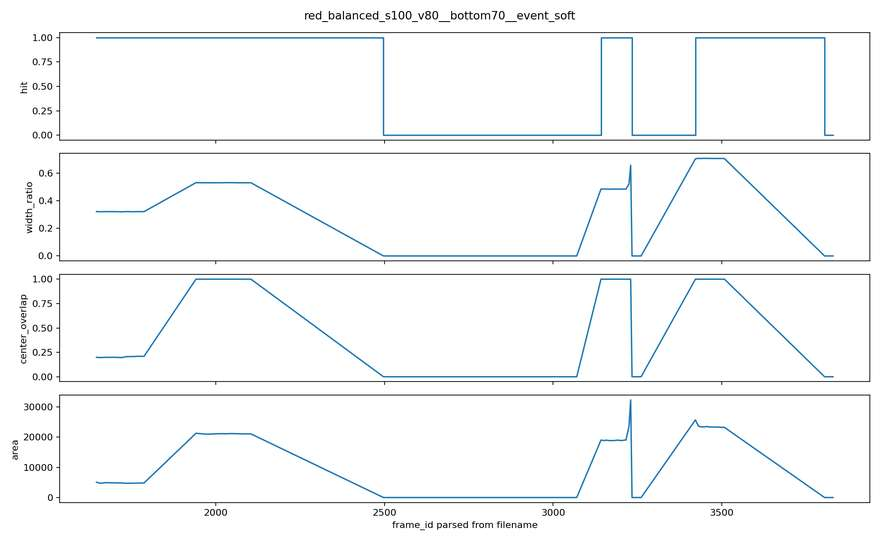

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\plots\timeline__red_balanced_s100_v80__bottom70__event_balanced.png


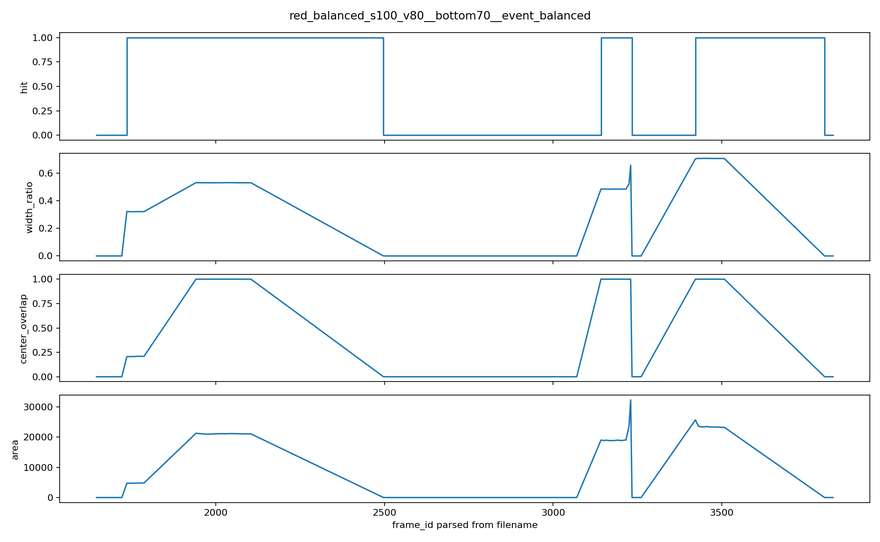

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\plots\timeline__red_conservative_s130_v100__bottom75__event_close.png


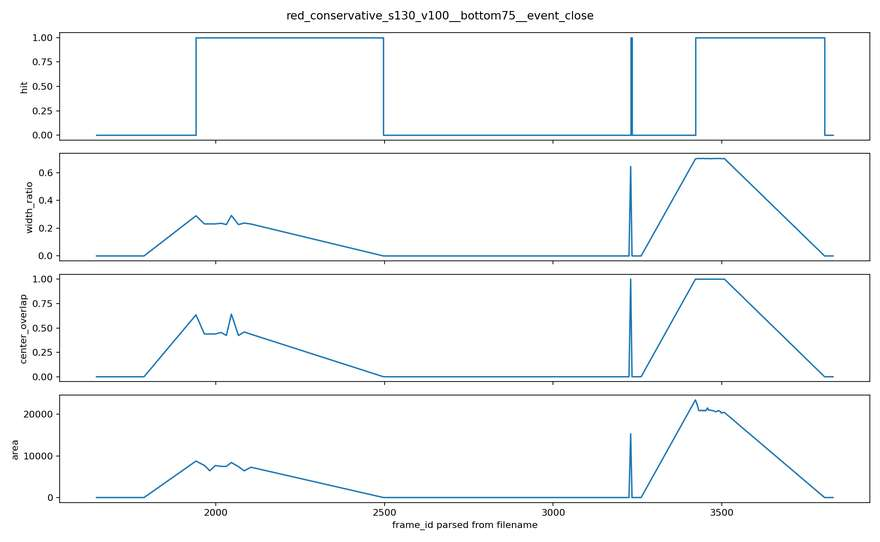

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\plots\timeline__red_conservative_s130_v100__bottom70__event_close.png


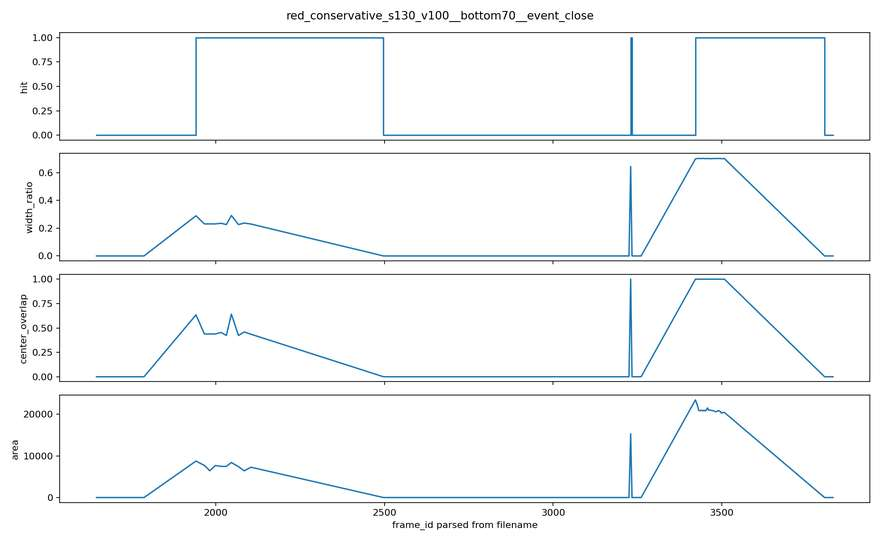

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\plots\timeline__red_conservative_s130_v100__bottom80__event_close.png


In [8]:
def timeline_for_candidate(profile_name, roi_name, shape_name):
    final_df = index_df[index_df['role'] == 'final_redline'].sort_values('frame_id').reset_index(drop=True)
    rows=[]
    profile = next(p for p in HSV_PROFILES_TO_EVALUATE if p['name'] == profile_name)
    roi = next(r for r in ROI_CANDIDATES if r['name'] == roi_name)
    shape = next(s for s in EVENT_SHAPE_CANDIDATES if s['name'] == shape_name)
    for _, rec in final_df.iterrows():
        bgr = imread_bgr(rec['path'])
        passed, feats, _ = detect_redline_event_candidates(bgr, profile, roi, shape)
        best = passed[0] if passed else None
        rows.append({
            'filename': rec['filename'],
            'frame_id': rec['frame_id'],
            'hit': int(best is not None),
            'best_area': best['area'] if best else 0.0,
            'best_width_ratio': best['width_ratio'] if best else 0.0,
            'best_center_overlap': best['center_overlap'] if best else 0.0,
            'best_cy': best['cy'] if best else np.nan,
            'best_bottom_y': best['bottom_y'] if best else np.nan,
        })
    return pd.DataFrame(rows)

def plot_timeline(df, title, out_path):
    fig, axes = plt.subplots(4, 1, figsize=(13, 8), sharex=True)
    axes[0].plot(df['frame_id'], df['hit'], drawstyle='steps-post')
    axes[0].set_ylabel('hit')
    axes[0].set_ylim(-0.05, 1.05)
    axes[1].plot(df['frame_id'], df['best_width_ratio'])
    axes[1].set_ylabel('width_ratio')
    axes[2].plot(df['frame_id'], df['best_center_overlap'])
    axes[2].set_ylabel('center_overlap')
    axes[3].plot(df['frame_id'], df['best_area'])
    axes[3].set_ylabel('area')
    axes[3].set_xlabel('frame_id parsed from filename')
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)
    return out_path

# 상위 후보 5개의 timeline을 그린다.
top5 = pivot.head(5)[['profile','roi','shape']].drop_duplicates()
timeline_tables = []
for _, row in top5.iterrows():
    df = timeline_for_candidate(row['profile'], row['roi'], row['shape'])
    tag = f"{row['profile']}__{row['roi']}__{row['shape']}"
    df.to_csv(TABLE_DIR / f'timeline__{tag}.csv', index=False, encoding='utf-8-sig')
    out = PLOT_DIR / f'timeline__{tag}.png'
    plot_timeline(df, tag, out)
    print(out)
    show_saved_image(out, width=1000)
    timeline_tables.append((tag, df))


## Overlay 생성

상위 후보를 눈으로 확인한다.

색상 의미:

```text
노란 bbox: event 조건을 통과한 contour
빨간 bbox: mask contour 중 event 조건은 통과하지 못한 contour
파란 선: bottom ROI 시작선
초록 세로 band: 중앙 주행 영역
```


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\overlays\event__red_balanced_s100_v80__bottom70__event_soft__final_redline__hit.jpg


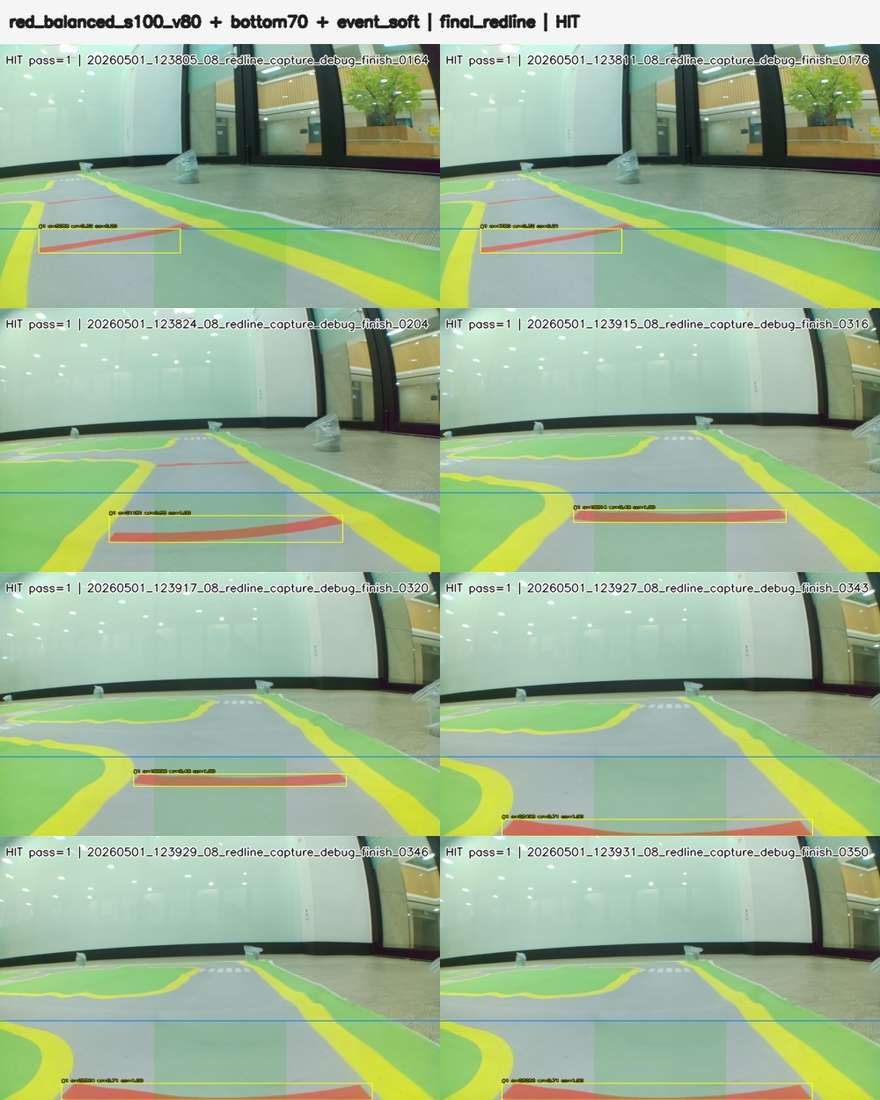

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\overlays\event__red_balanced_s100_v80__bottom70__event_soft__final_redline__miss.jpg


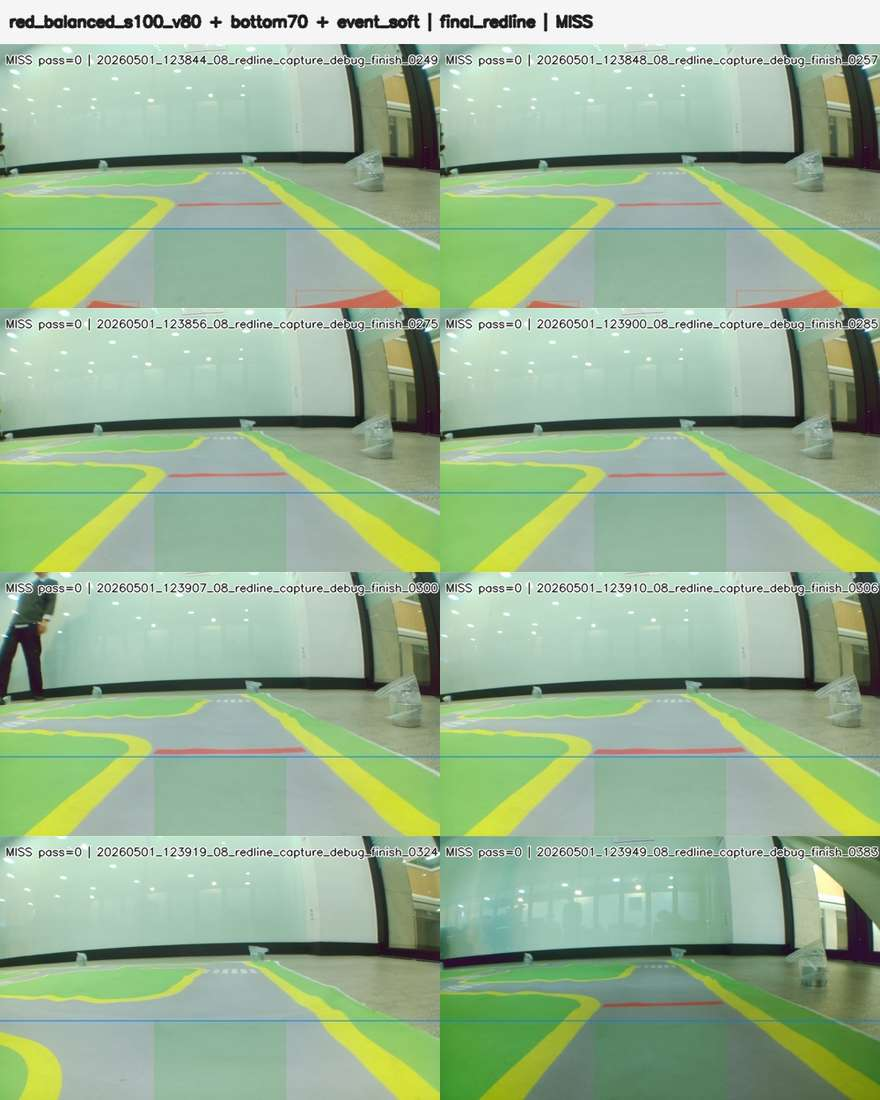

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\overlays\event__red_balanced_s100_v80__bottom70__event_soft__stop_sign_negative__hit.jpg


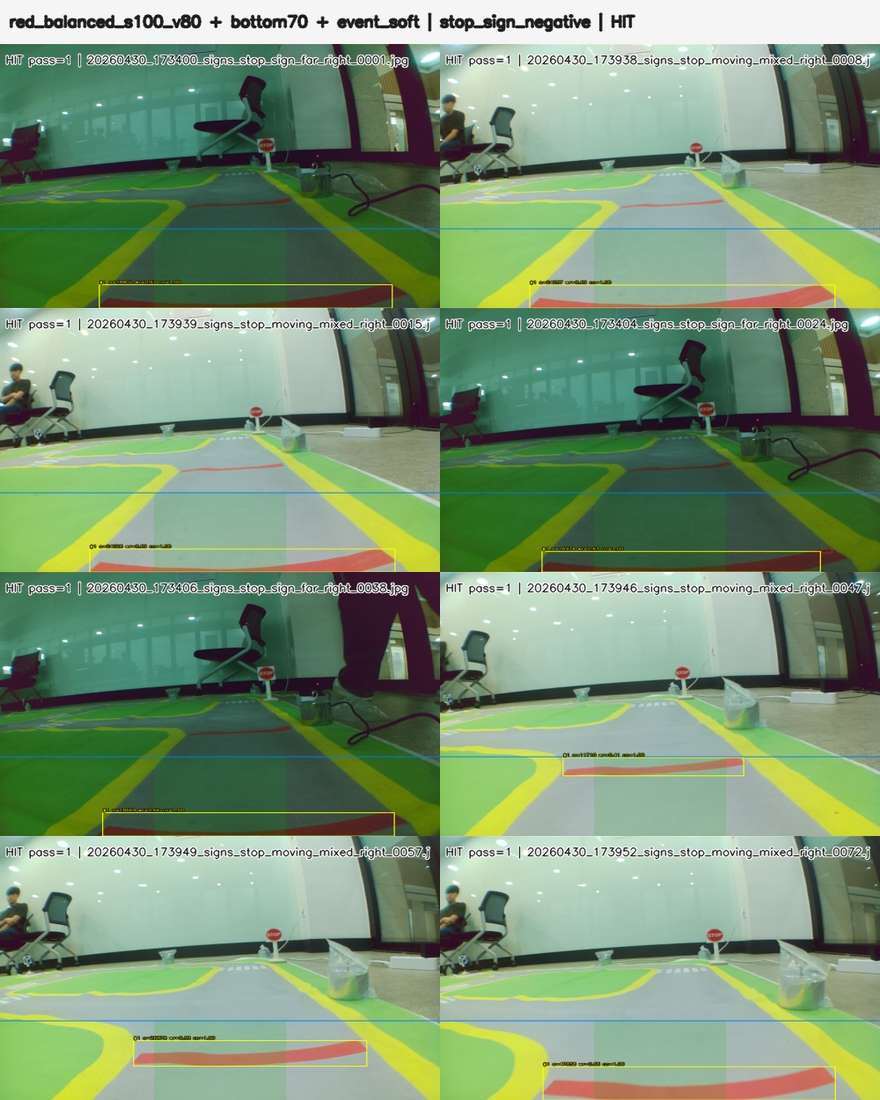

no selected rows: red_balanced_s100_v80 bottom70 event_soft traffic_red True
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\overlays\event__red_balanced_s100_v80__bottom70__event_balanced__final_redline__hit.jpg


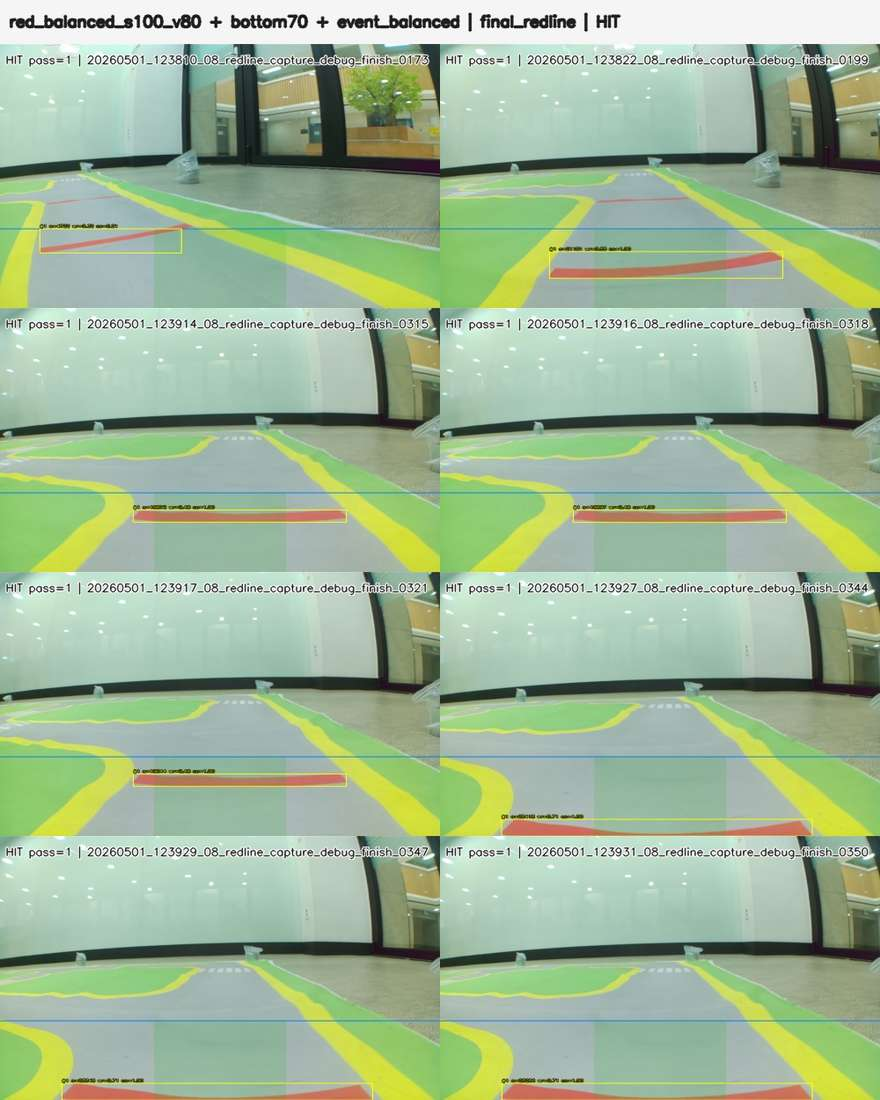

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\overlays\event__red_balanced_s100_v80__bottom70__event_balanced__final_redline__miss.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\overlays\event__red_balanced_s100_v80__bottom70__event_balanced__stop_sign_negative__hit.jpg


no selected rows: red_balanced_s100_v80 bottom70 event_balanced traffic_red True
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\overlays\event__red_conservative_s130_v100__bottom75__event_close__final_redline__hit.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\overlays\event__red_conservative_s130_v100__bottom75__event_close__final_redline__miss.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\overlays\event__red_conservative_s130_v100__bottom75__event_close__stop_sign_negative__hit.jpg


no selected rows: red_conservative_s130_v100 bottom75 event_close traffic_red True
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\overlays\event__red_conservative_s130_v100__bottom70__event_close__final_redline__hit.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\overlays\event__red_conservative_s130_v100__bottom70__event_close__final_redline__miss.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\02a_redline_bottom_roi_event_probe_v1\overlays\event__red_conservative_s130_v100__bottom70__event_close__stop_sign_negative__hit.jpg


no selected rows: red_conservative_s130_v100 bottom70 event_close traffic_red True


In [9]:
def draw_event_overlay(bgr, profile, roi, shape):
    H, W = bgr.shape[:2]
    passed, feats, roi_mask = detect_redline_event_candidates(bgr, profile, roi, shape)
    out = bgr.copy()
    # ROI line
    y0 = int(round(roi['y0'] * H))
    cv2.line(out, (0, y0), (W-1, y0), (255, 120, 0), 2)
    # central band
    bx0 = int(round(CENTRAL_BAND[0] * W))
    bx1 = int(round(CENTRAL_BAND[1] * W))
    overlay = out.copy()
    cv2.rectangle(overlay, (bx0, y0), (bx1, H-1), (0, 180, 0), -1)
    out = cv2.addWeighted(out, 0.88, overlay, 0.12, 0)
    # all contours weak red
    for f in feats[:12]:
        x,y,w,h = f['x'], f['y'], f['w'], f['h']
        cv2.rectangle(out, (x,y), (x+w,y+h), (0,80,255), 1)
    # passed strong yellow
    for i, f in enumerate(passed[:6]):
        x,y,w,h = f['x'], f['y'], f['w'], f['h']
        cv2.rectangle(out, (x,y), (x+w,y+h), (0,255,255), 2)
        txt = f"#{i+1} a={f['area']:.0f} wr={f['width_ratio']:.2f} co={f['center_overlap']:.2f}"
        cv2.putText(out, txt, (x, max(20, y-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (0,0,0), 3, cv2.LINE_AA)
        cv2.putText(out, txt, (x, max(20, y-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (0,255,255), 1, cv2.LINE_AA)
    return out, passed

def make_event_sheet(profile_name, roi_name, shape_name, role, want_hit, out_path, n=8, cols=2):
    profile = next(p for p in HSV_PROFILES_TO_EVALUATE if p['name'] == profile_name)
    roi = next(r for r in ROI_CANDIDATES if r['name'] == roi_name)
    shape = next(s for s in EVENT_SHAPE_CANDIDATES if s['name'] == shape_name)
    df = index_df[index_df['role'] == role].sort_values('frame_id').reset_index(drop=True)
    selected=[]
    for _, rec in df.iterrows():
        bgr = imread_bgr(rec['path'])
        _, passed = draw_event_overlay(bgr, profile, roi, shape)
        is_hit = len(passed) > 0
        if is_hit == want_hit:
            selected.append(rec)
    if not selected:
        print('no selected rows:', profile_name, roi_name, shape_name, role, want_hit)
        return None
    idx = np.linspace(0, len(selected)-1, min(n, len(selected)), dtype=int)
    selected = [selected[i] for i in idx]
    cell_w, cell_h = 500, 300
    rows = int(math.ceil(len(selected) / cols))
    canvas = np.full((rows*cell_h + 50, cols*cell_w, 3), 245, dtype=np.uint8)
    title = f'{profile_name} + {roi_name} + {shape_name} | {role} | {"HIT" if want_hit else "MISS"}'
    cv2.putText(canvas, title[:120], (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.58, (30,30,30), 2, cv2.LINE_AA)
    for i, rec in enumerate(selected):
        bgr = imread_bgr(rec['path'])
        drawn, passed = draw_event_overlay(bgr, profile, roi, shape)
        drawn = cv2.resize(drawn, (cell_w, cell_h), interpolation=cv2.INTER_AREA)
        r,c = i//cols, i%cols
        y,x = 50 + r*cell_h, c*cell_w
        canvas[y:y+cell_h, x:x+cell_w] = drawn
        txt = f'{"HIT" if passed else "MISS"} pass={len(passed)} | {rec["filename"][:52]}'
        cv2.putText(canvas, txt, (x+6, y+22), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (255,255,255), 2, cv2.LINE_AA)
        cv2.putText(canvas, txt, (x+6, y+22), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (20,20,20), 1, cv2.LINE_AA)
    imwrite(out_path, canvas)
    return out_path

shortlist = pivot.head(4)[['profile','roi','shape']].drop_duplicates().to_dict('records')
for cand in shortlist:
    tag = f"{cand['profile']}__{cand['roi']}__{cand['shape']}"
    for role, want_hit in [
        ('final_redline', True),
        ('final_redline', False),
        ('stop_sign_negative', True),
        ('traffic_red', True),
    ]:
        out = OVERLAY_DIR / f'event__{tag}__{role}__{"hit" if want_hit else "miss"}.jpg'
        p = make_event_sheet(cand['profile'], cand['roi'], cand['shape'], role, want_hit, out, n=8)
        if p is not None:
            print(p)
            show_saved_image(p, width=1000)


## 02a 결과를 읽는 법

이 노트북에서 바로 볼 것은 세 가지다.

```text
1. bottom_roi_event_candidate_ranking.csv
   - bottom ROI와 shape 조건이 어떤 trade-off를 만드는지 본다.

2. timeline plot
   - final redline sequence에서 hit가 언제 켜지는지 본다.
   - 너무 이르면 false trigger 위험, 너무 늦으면 정지 타이밍이 늦다.

3. event overlay
   - 노란 bbox가 정말 하단 redline인지 본다.
   - stop_sign_negative에서 hit가 났다면 stop sign 자체인지, 바닥 빨간 영역인지 구분한다.
```

다음 단계에서 provisional contract를 만든다면 아래 값들이 들어간다.

```json
{
  "hsv_profile": "red_balanced_s100_v80",
  "bottom_roi_y0": 0.75,
  "shape_filter": "event_balanced or event_close",
  "temporal_voting": "2~3 consecutive frames",
  "stop_delay_sec": "motor speed에 따라 실험으로 조정"
}
```

아직 `bottom_roi_y0`, `shape_filter`, `stop_delay_sec`는 확정하지 않는다. 이번 노트북의 목적은 후보를 좁히는 것이다.
